### ***IMPORT LIBRARIES***

In [1]:
#import all necessary libriries
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam
from pathlib import Path
from warnings import simplefilter
import numpy as np
from sklearn.metrics import precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess

simplefilter("ignore")

2024-08-09 21:59:15.674747: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-09 21:59:15.674892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-09 21:59:15.835859: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### ***MAKE PLOT OF THE DATA***

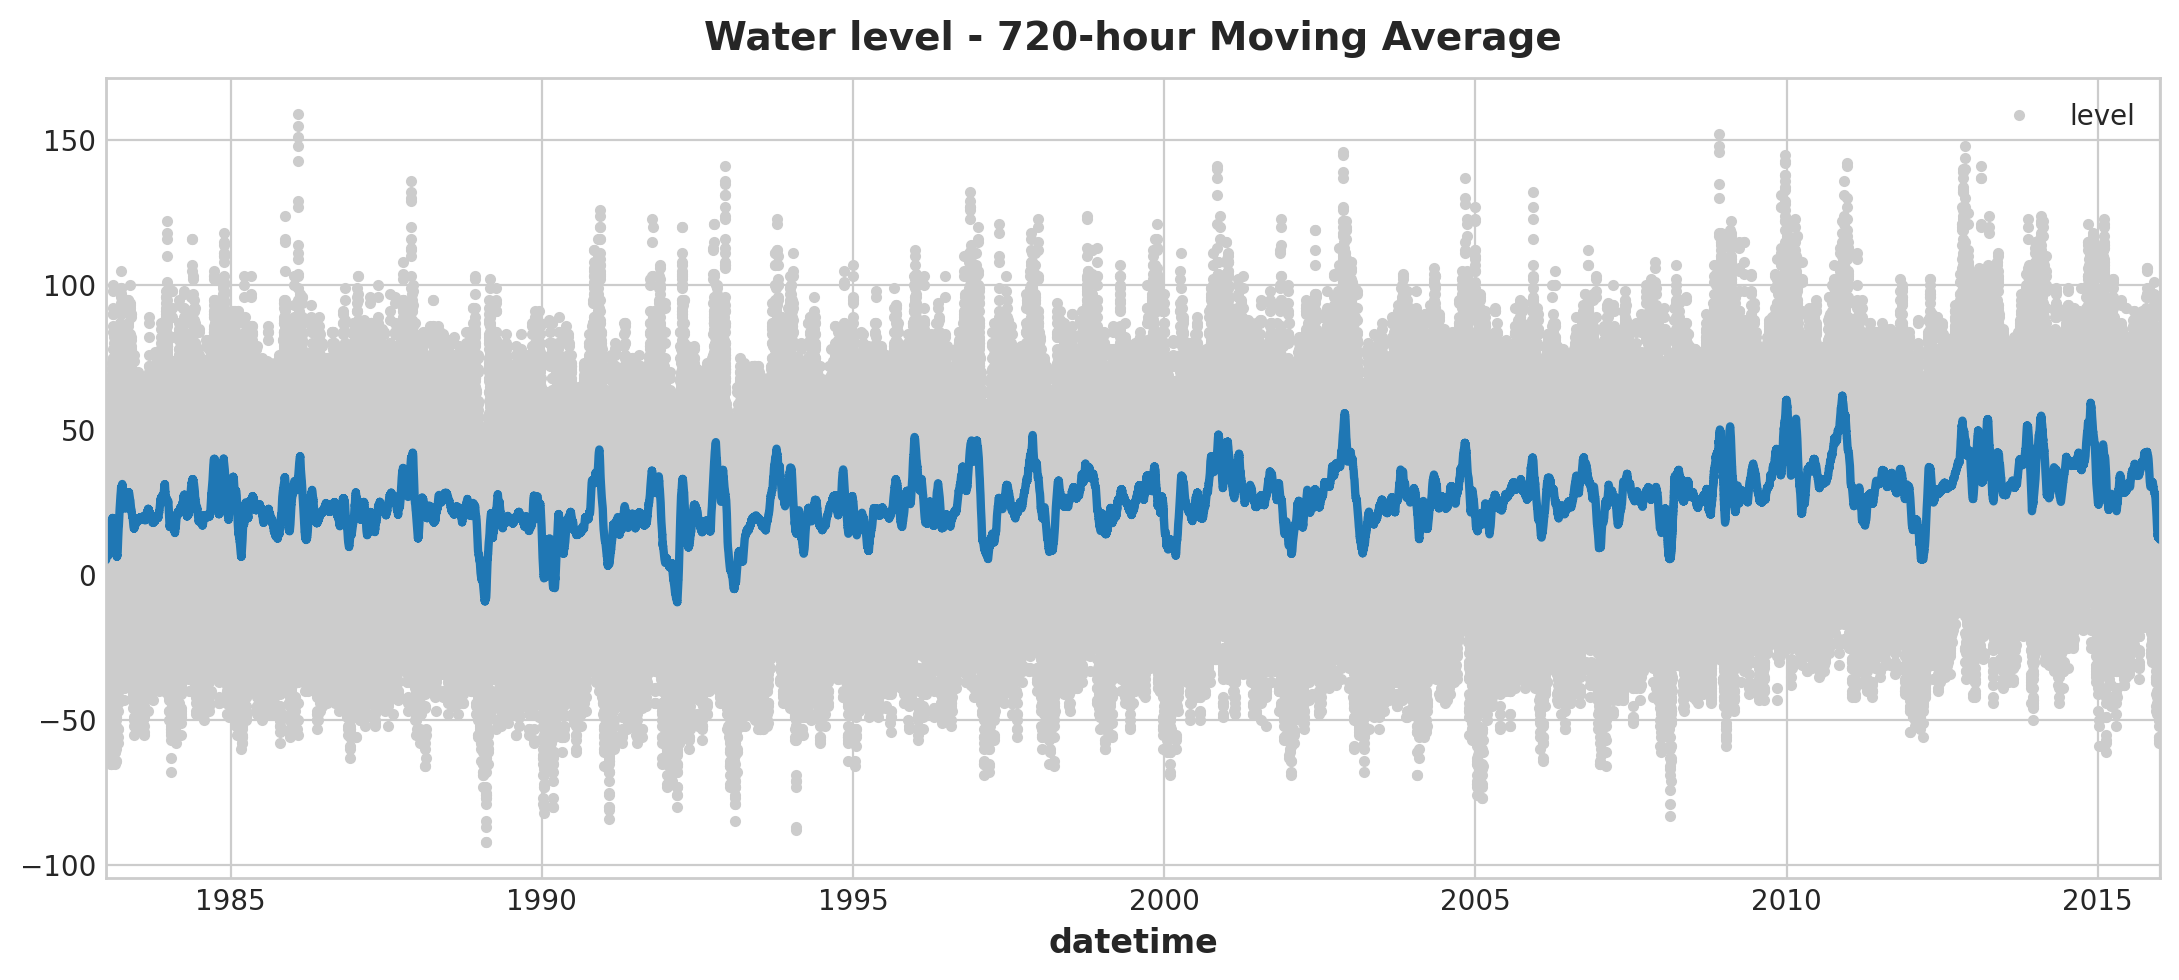

In [2]:
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'
# Load Tunnel Traffic dataset
df = pd.read_csv('/kaggle/input/venezia-csv/venezia.csv', parse_dates=["datetime"])
df = df.set_index("datetime").to_period('H')

moving_average = df.rolling(
    window=720,       # 365-day window
    center=True,      # puts the average at the center of the window
    min_periods=360,  # choose about half the window size
).mean()              # compute the mean (could also do median, std, min, max, ...)

ax = df.plot(style=".", color="0.8")
moving_average.plot(
    ax=ax, linewidth=3, title="Water level - 720-hour Moving Average", legend=False,
);

In [3]:
# Set Matplotlib defaults
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)
%config InlineBackend.figure_format = 'retina'


# annotations: https://stackoverflow.com/a/49238256/5769929
def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique())
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax


def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1H")
    freqencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(freqencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104, 365, 8760])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
            "Daily (365)",
            "Hourly (8760)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax


In [4]:
data_dir = Path("/kaggle/input/venezia-csv/venezia.csv")
df = pd.read_csv(data_dir, parse_dates=["datetime"])
df = df.set_index("datetime").to_period("H")

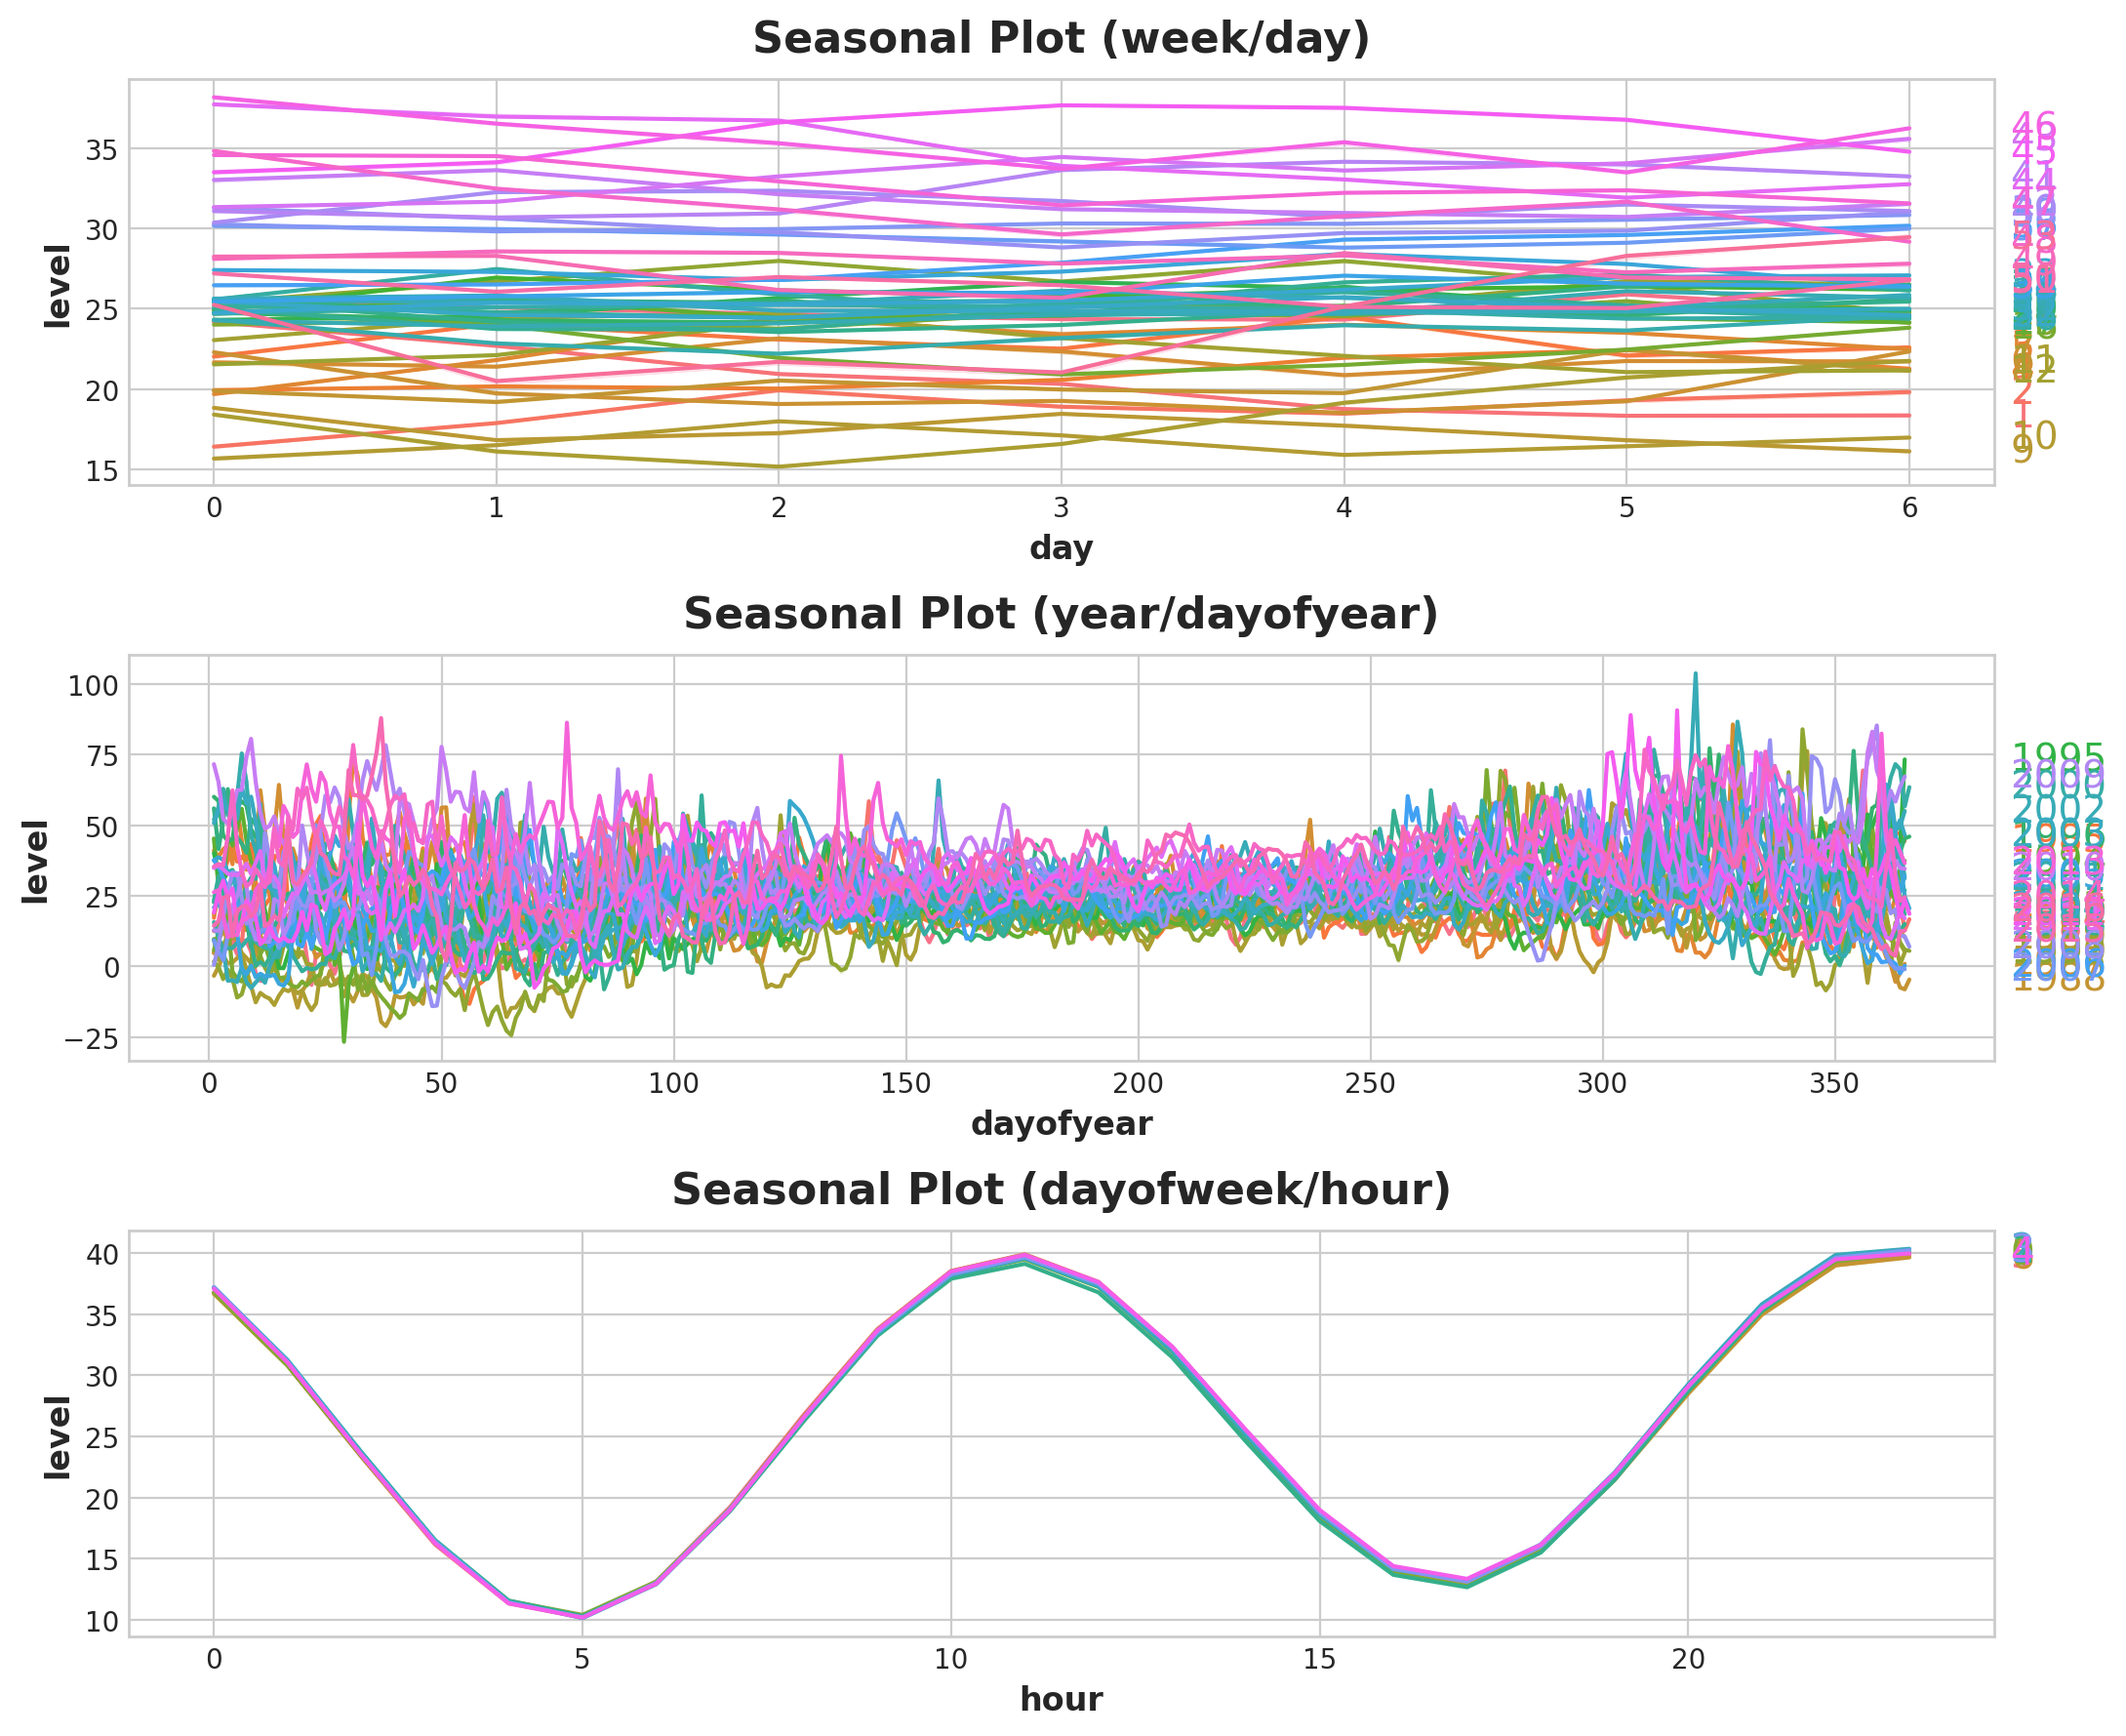

In [5]:
X = df.copy()

# Add columns for seasonal plotting
# days within a week
X["day"] = X.index.dayofweek  # the x-axis (freq)
X["week"] = X.index.week  # the seasonal period (period)

# days within a year
X["dayofyear"] = X.index.dayofyear
X["year"] = X.index.year

# Add columns for hour of the day
X["hour"] = X.index.hour  # the x-axis (freq)
X["dayofweek"] = X.index.dayofweek  # the seasonal period (period)

fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(11, 9))

# Weekly seasonal plot
seasonal_plot(X, y="level", period="week", freq="day", ax=ax0)

# Yearly seasonal plot
seasonal_plot(X, y="level", period="year", freq="dayofyear", ax=ax1)

# Hourly seasonal plot
seasonal_plot(X, y="level", period="dayofweek", freq="hour", ax=ax2)

#plt.tight_layout()
plt.show()


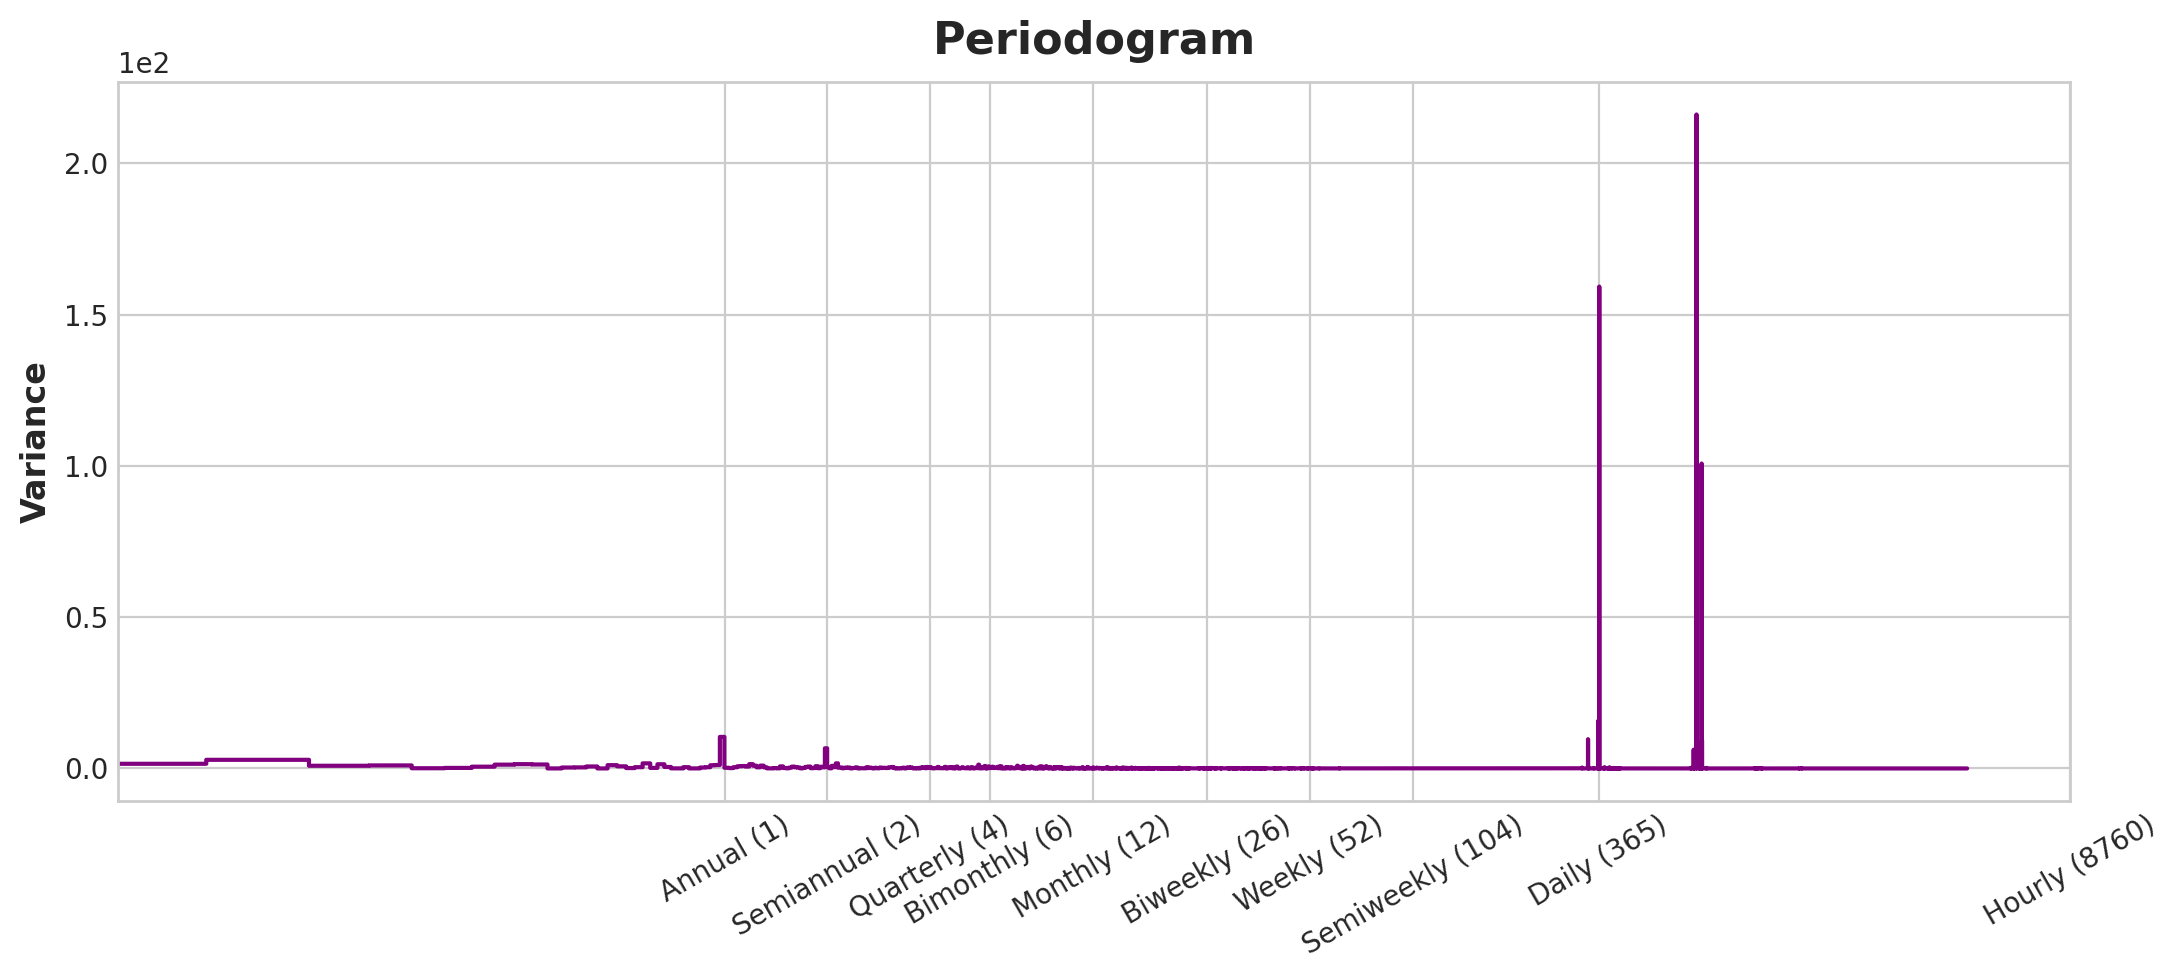

In [6]:
plot_periodogram(df.level);

### ***LOAD DATA AND SET DATETIME AS INDEX***

In [7]:

# Load the dataset
df = pd.read_csv('/kaggle/input/venezia-csv/venezia.csv')  # Replace with your actual dataset file path
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

In [8]:
df.head()

,level
datetime,
1983-01-01 01:00:00,44.0
1983-01-01 02:00:00,35.0
1983-01-01 03:00:00,23.0
1983-01-01 04:00:00,10.0
1983-01-01 05:00:00,1.0


In [9]:
def classify(x):
    if x < (0.8 * 105):
        return 0
    elif x < 105:
        return 1
    else:
        return 2

In [10]:
len(df['level'])

289272

In [11]:
df['level'] = df['level'].apply(classify )
df.head()

,level
datetime,
1983-01-01 01:00:00,0
1983-01-01 02:00:00,0
1983-01-01 03:00:00,0
1983-01-01 04:00:00,0
1983-01-01 05:00:00,0


## ***SEASONALITY PREDICTION***

### ***CREATE SEASONALITY FEATURES***

In [12]:
# Feature Engineering for XGBoost
def create_date_features(df, label):
    
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['bidaily'] = (np.arange(len(df))%2)+1
    return df.drop(label, axis = 1), df[label]


In [13]:
def create_lag_features(df, n_lags):
    df['col_0'] = df['level'].shift()
    for i in range(1, n_lags):
       df[f'col_{i}'] = df[f'col_{i-1}'].shift()
    return df.fillna(0)

In [14]:
n_lags = 12  # 24 hours lag
df = create_lag_features(df, 12)
X, y = create_date_features(df, label='level')

In [15]:
X.head(10)

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,hour,dayofweek,month,quarter,year,bidaily
datetime,,,,,,,,,,,,,,,,,,
1983-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5,1,1,1983,1
1983-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,5,1,1,1983,2
1983-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5,1,1,1983,1
1983-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,5,1,1,1983,2
1983-01-01 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,5,1,1,1983,1
1983-01-01 06:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,5,1,1,1983,2
1983-01-01 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,1,1,1983,1
1983-01-01 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,5,1,1,1983,2
1983-01-01 09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,5,1,1,1983,1


### ***TRAIN TEST SPLIT***

In [16]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [17]:
_, X_val, _, y_val = train_test_split(X_test, y_test, test_size=0.4, shuffle=False)

In [18]:
X_test.shape

(57855, 18)

### ***TRAIN LSTM FOR LONG TERM***

In [19]:
class MetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super(MetricsCallback, self).__init__()
        self.validation_data = validation_data
        self.history = {'val_precision': [], 'val_recall': []}
    
    def on_epoch_end(self, epoch, logs=None):
        # Get model predictions
        val_pred_proba = self.model.predict(self.validation_data[0])
        # Convert probabilities to class labels
        val_predict = np.argmax(val_pred_proba, axis=1)
        val_targ = self.validation_data[1]
        
        # Compute precision and recall
        precision = precision_score(val_targ, val_predict, average='macro')
        recall = recall_score(val_targ, val_predict, average='macro')
        
        # Store the metrics
        self.history['val_precision'].append(precision)
        self.history['val_recall'].append(recall)

        print(f' — val_precision: {precision:.4f} — val_recall: {recall:.4f}')
metrics_callback = MetricsCallback(validation_data=(X_val, y_val))

In [20]:
class_counts = np.bincount(y_train)

class_weight = class_counts.max() / class_counts
class_weight

array([  1.        ,  86.09385601, 639.79551821])

In [21]:
len(df.columns)

19

In [22]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(13, 1)))
model.add(tf.keras.layers.Dropout(0.2))
model.add(LSTM(64, activation = 'tanh'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(Dense(3, activation = 'softmax')) 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 13, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,163 (453.76 KB)

 Trainable params: 116,163 (453.76 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'X_val shape: {X_val.shape}')

X_train shape: (231417, 18)
X_test shape: (57855, 18)
X_val shape: (23142, 18)


In [24]:
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict


{0: 0.3377260766964235, 1: 29.07614021862043, 2: 216.07563025210084}

In [25]:
model.compile(optimizer=Adam(), 
              loss= tf.keras.losses.SparseCategoricalCrossentropy(), 
              metrics = ['accuracy'])

history = model.fit(X_train, y_train,
                    epochs=100, 
                    batch_size=32, 
                    #class_weight=class_weight_dict, 
                    verbose = 2, 
                    validation_data= (X_val, y_val),
                    callbacks=[metrics_callback]
                   )

Epoch 1/100
724/724 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step
 — val_precision: 0.6736 — val_recall: 0.5403
7232/7232 - 217s - 30ms/step - accuracy: 0.9888 - loss: 0.0445 - val_accuracy: 0.9762 - val_loss: 0.0823
Epoch 2/100
724/724 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
 — val_precision: 0.7251 — val_recall: 0.7126
7232/7232 - 217s - 30ms/step - accuracy: 0.9896 - loss: 0.0407 - val_accuracy: 0.9781 - val_loss: 0.0829
Epoch 3/100
724/724 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
 — val_precision: 0.7240 — val_recall: 0.7243
7232/7232 - 217s - 30ms/step - accuracy: 0.9890 - loss: 0.0428 - val_accuracy: 0.9781 - val_loss: 0.0804
Epoch 4/100
724/724 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
 — val_precision: 0.7832 — val_recall: 0.6283
7232/7232 - 214s - 30ms/step - accuracy: 0.9898 - loss: 0.0402 - val_accuracy: 0.9780 - val_loss: 0.0805
Epoch 5/100
724/724 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step
 — val_precision: 0.7538 — val_recall: 0.5582
7232/7232 - 213s - 30ms/step - accuracy: 0.9905 - loss: 0.0379 - val_accuracy: 

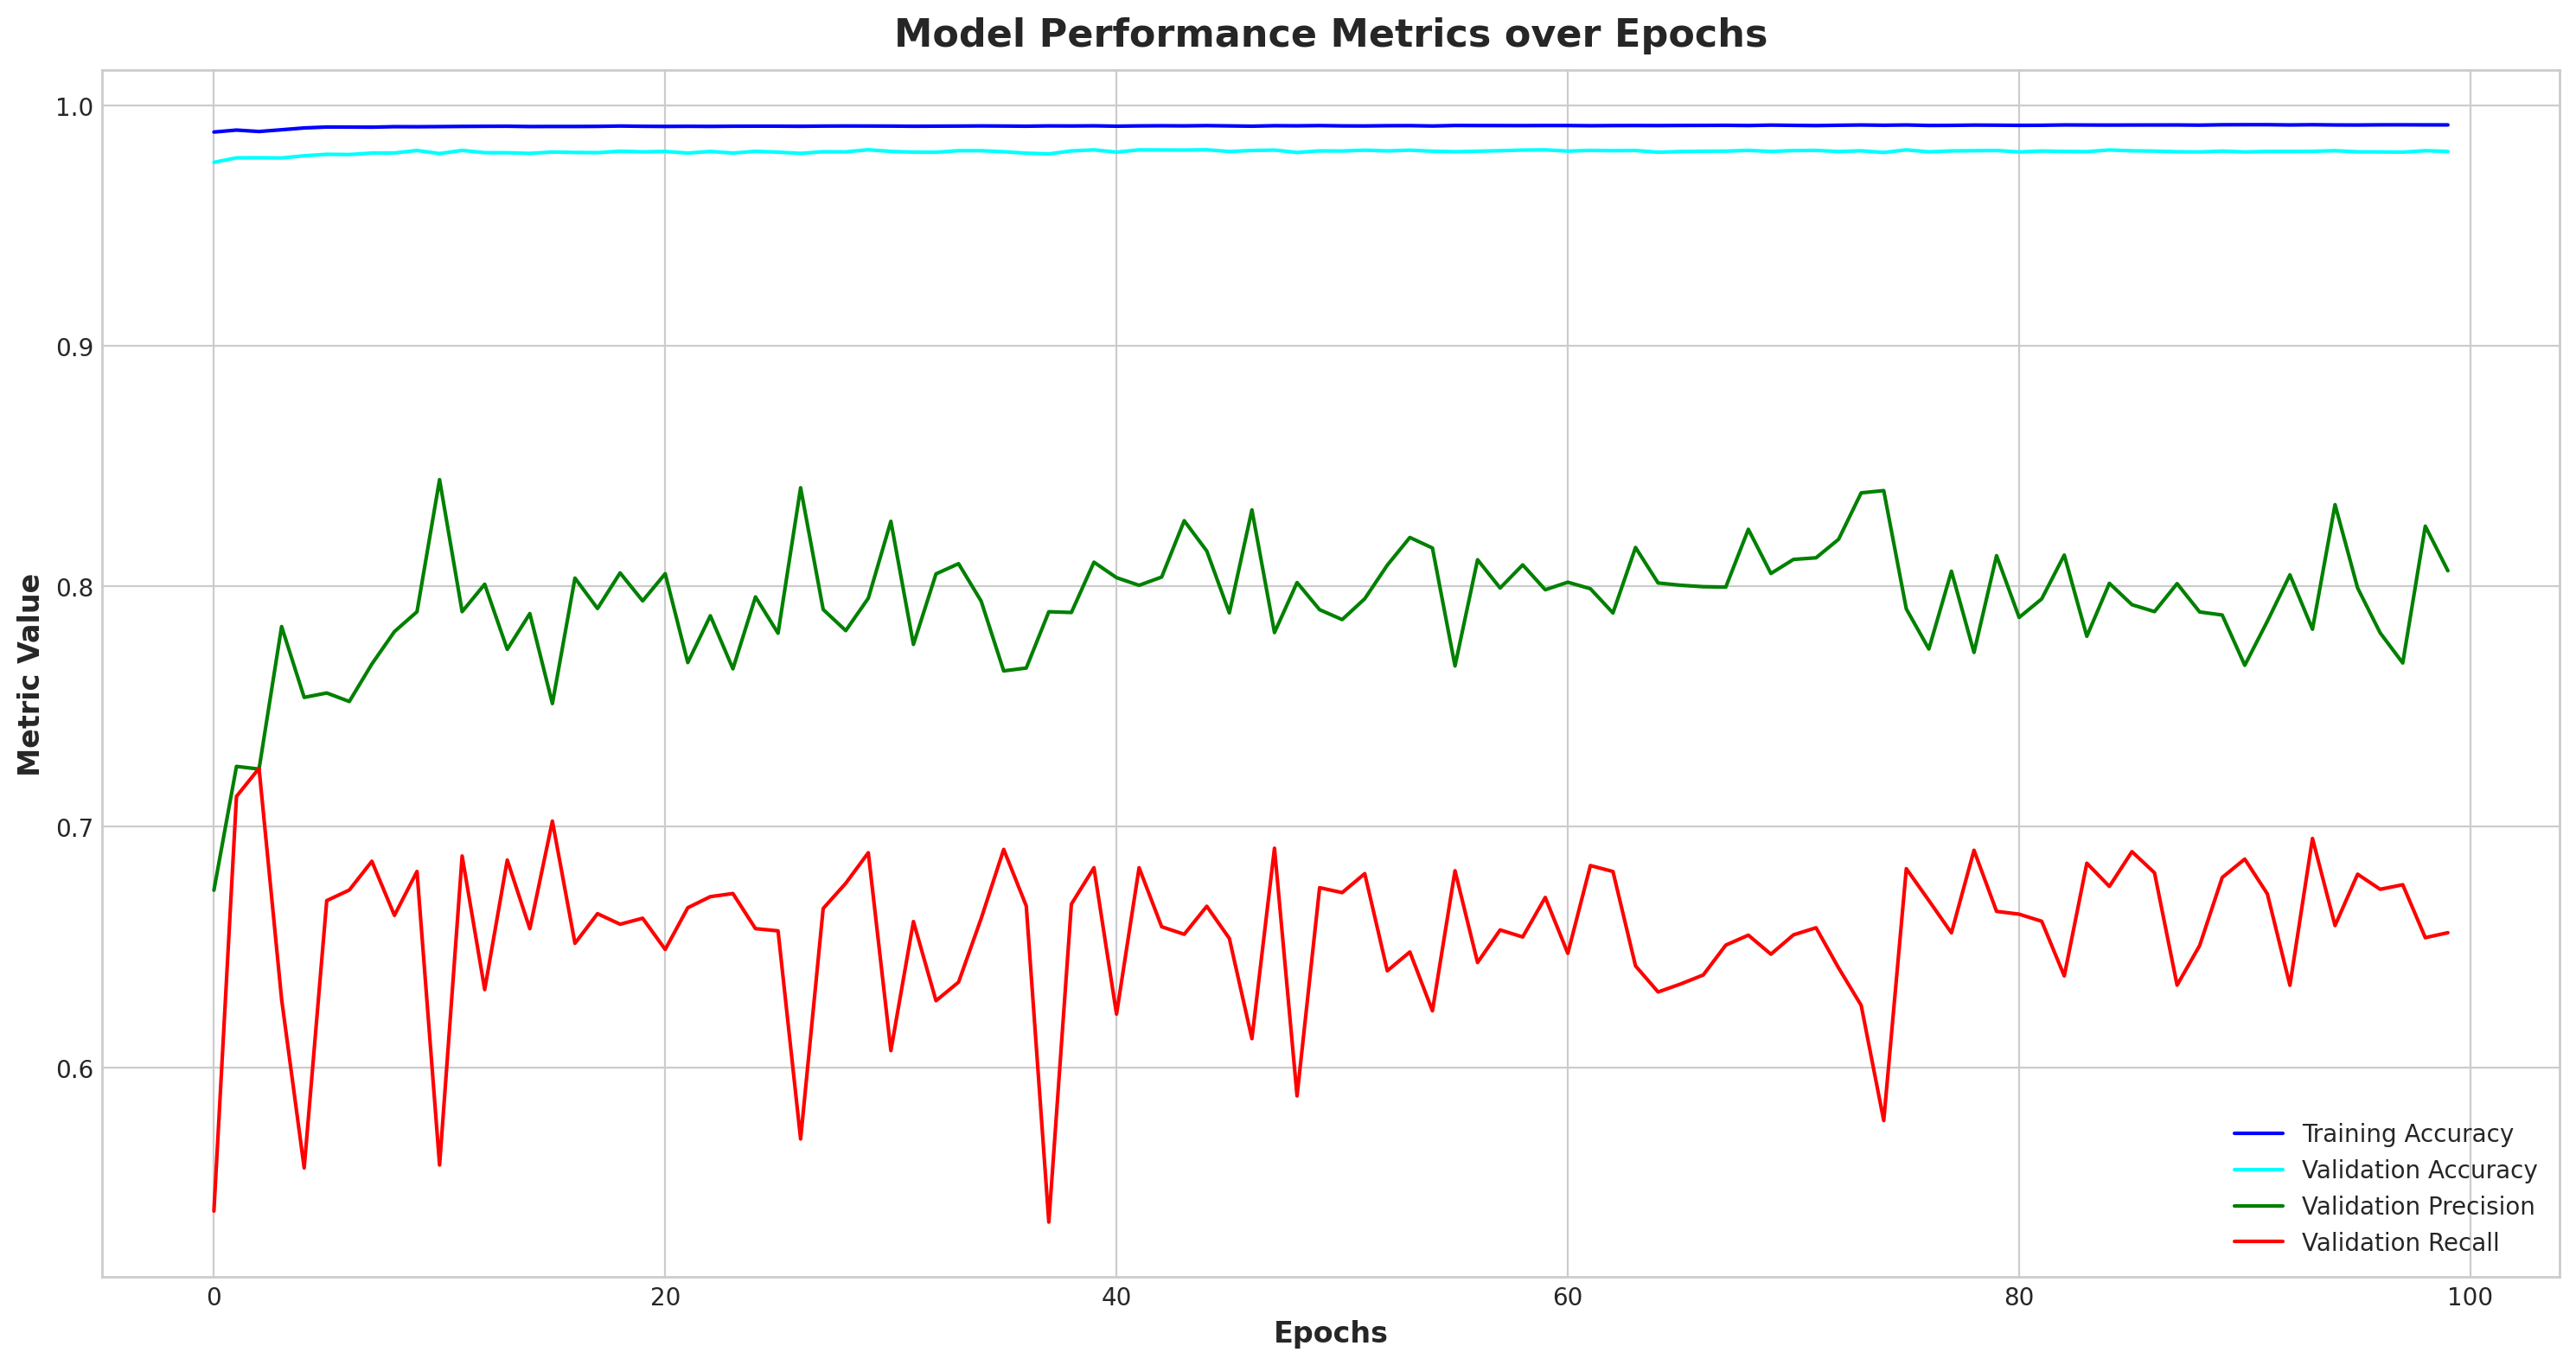

In [26]:
plt.figure(figsize=(15, 8))

plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='cyan')
plt.plot(metrics_callback.history['val_precision'], label='Validation Precision', color='green')
plt.plot(metrics_callback.history['val_recall'], label='Validation Recall', color='red')

plt.title('Model Performance Metrics over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Metric Value')
plt.legend()
plt.show()


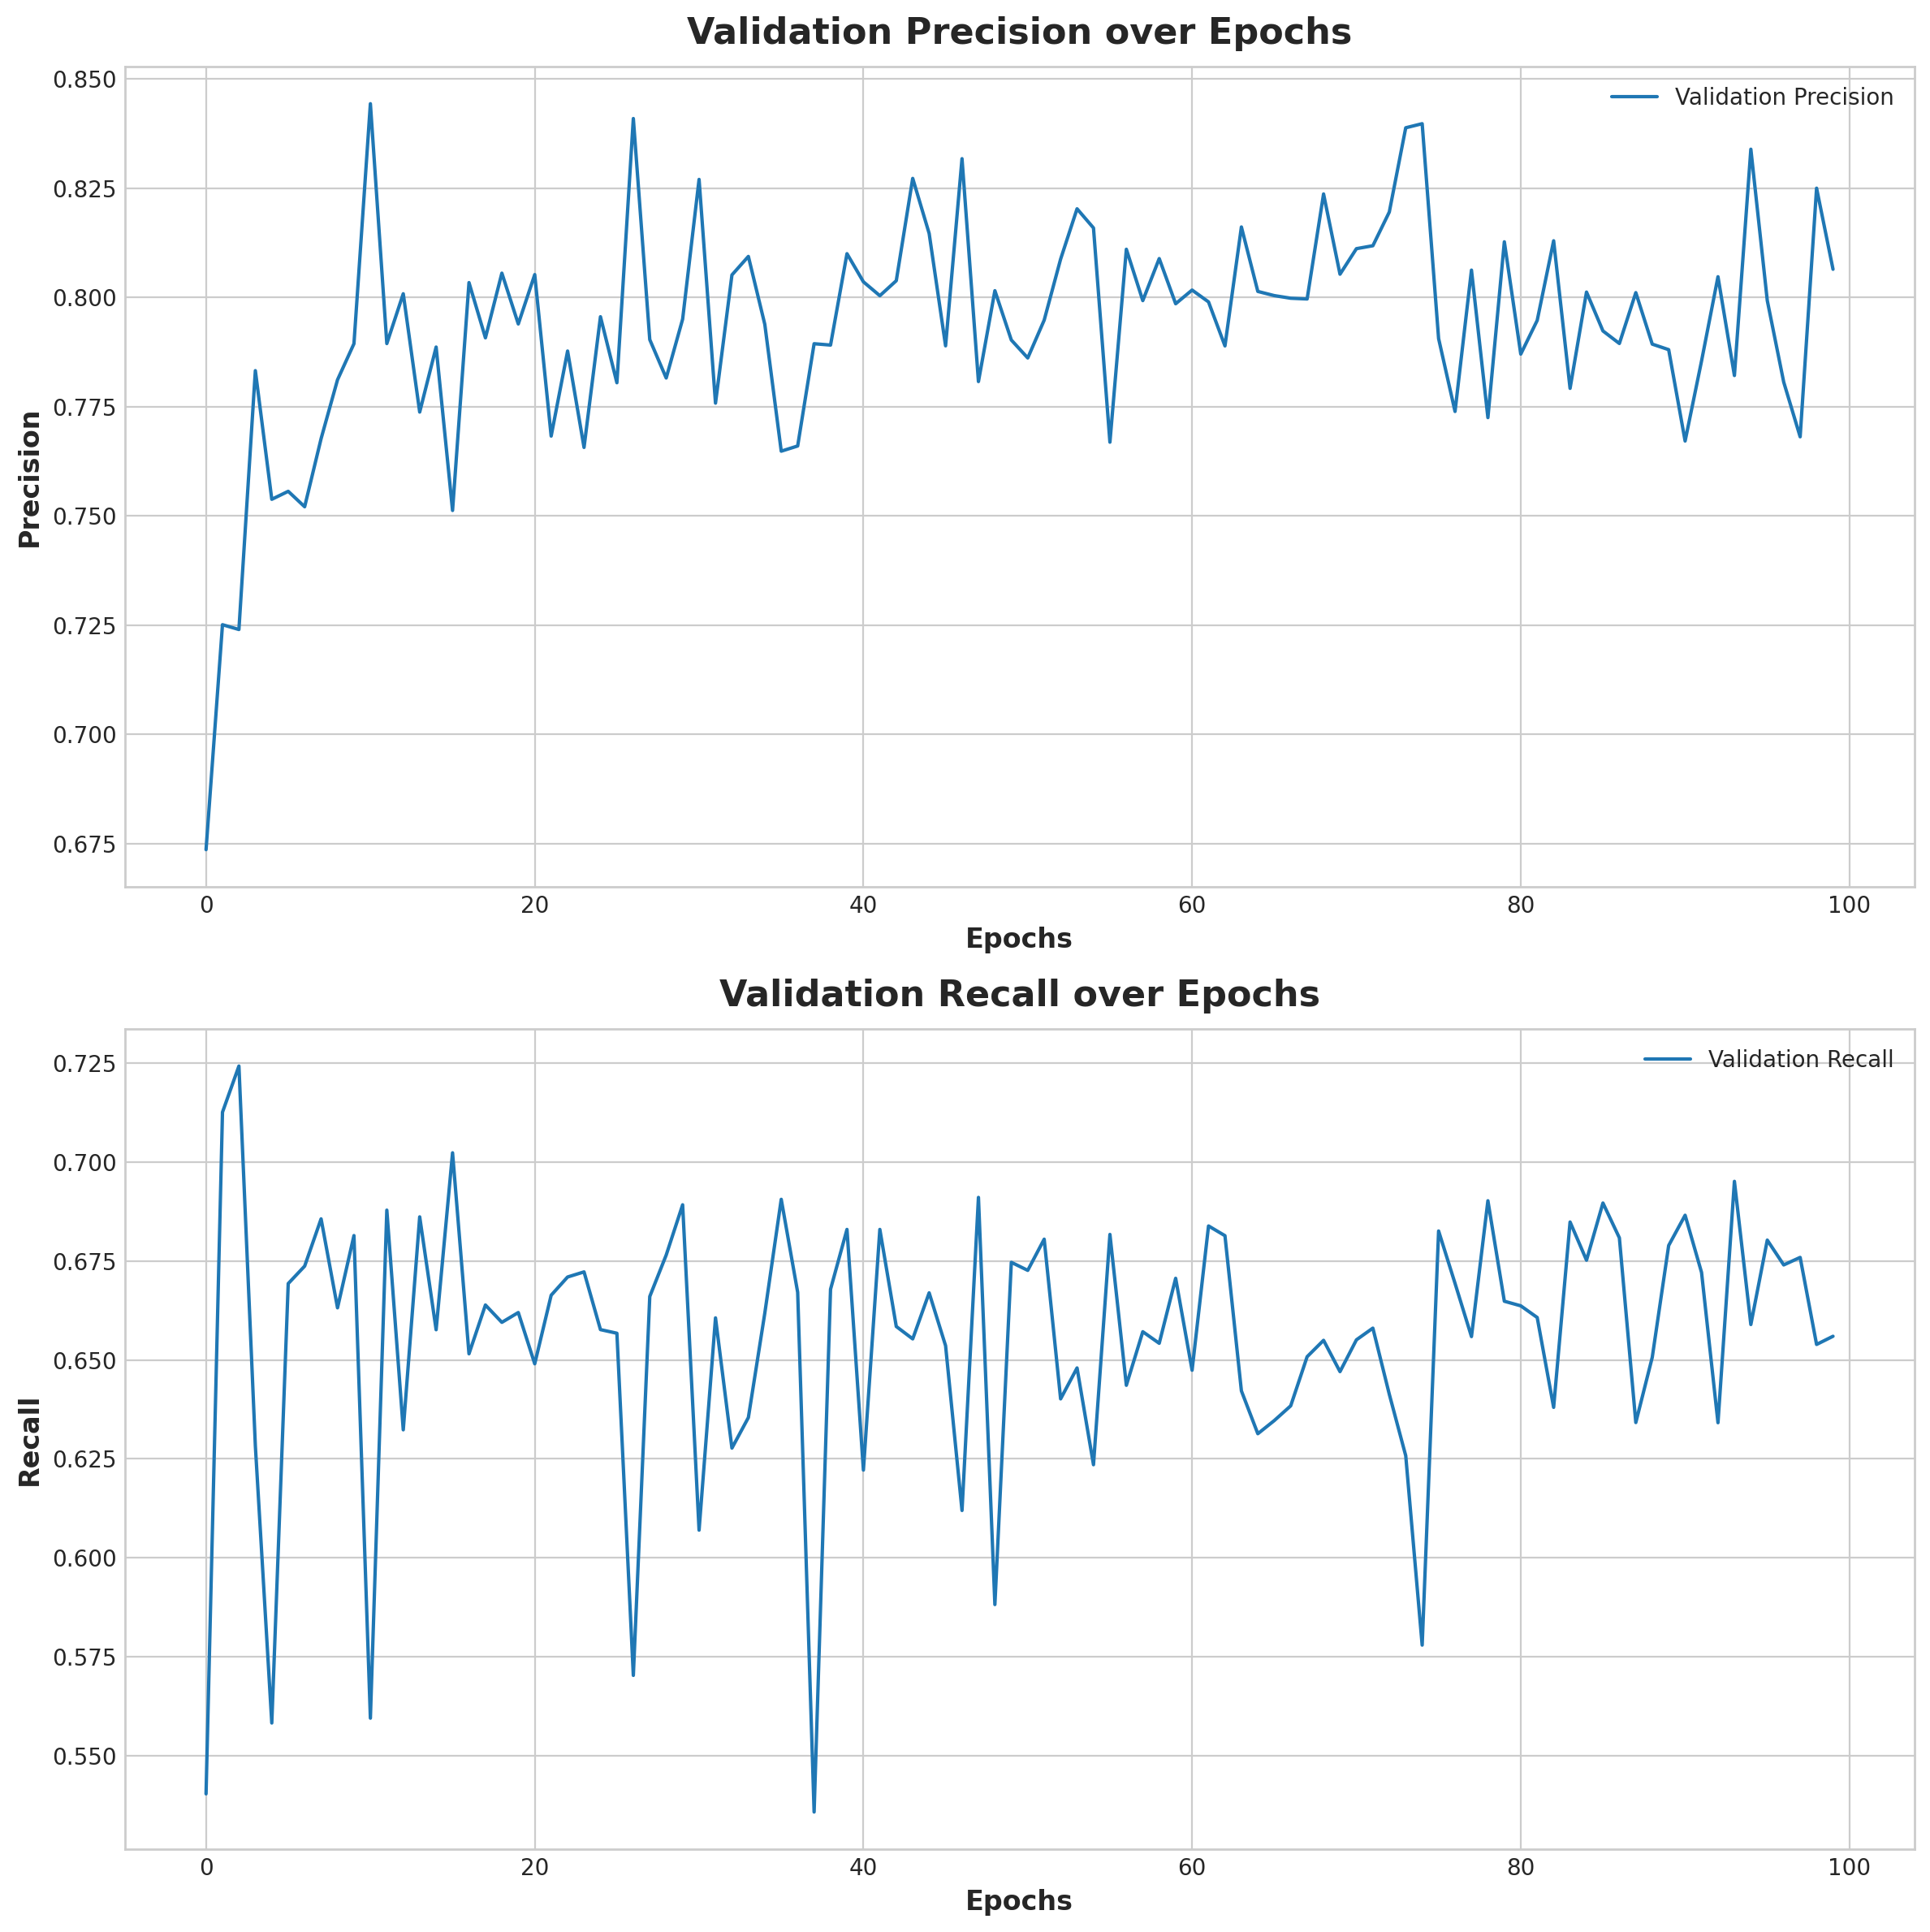

In [27]:
# Plot precision and recall
plt.figure(figsize=(12, 12))

plt.subplot(2, 1, 1)
plt.plot(metrics_callback.history['val_precision'], label='Validation Precision')
plt.title('Validation Precision over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(metrics_callback.history['val_recall'], label='Validation Recall')
plt.title('Validation Recall over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()

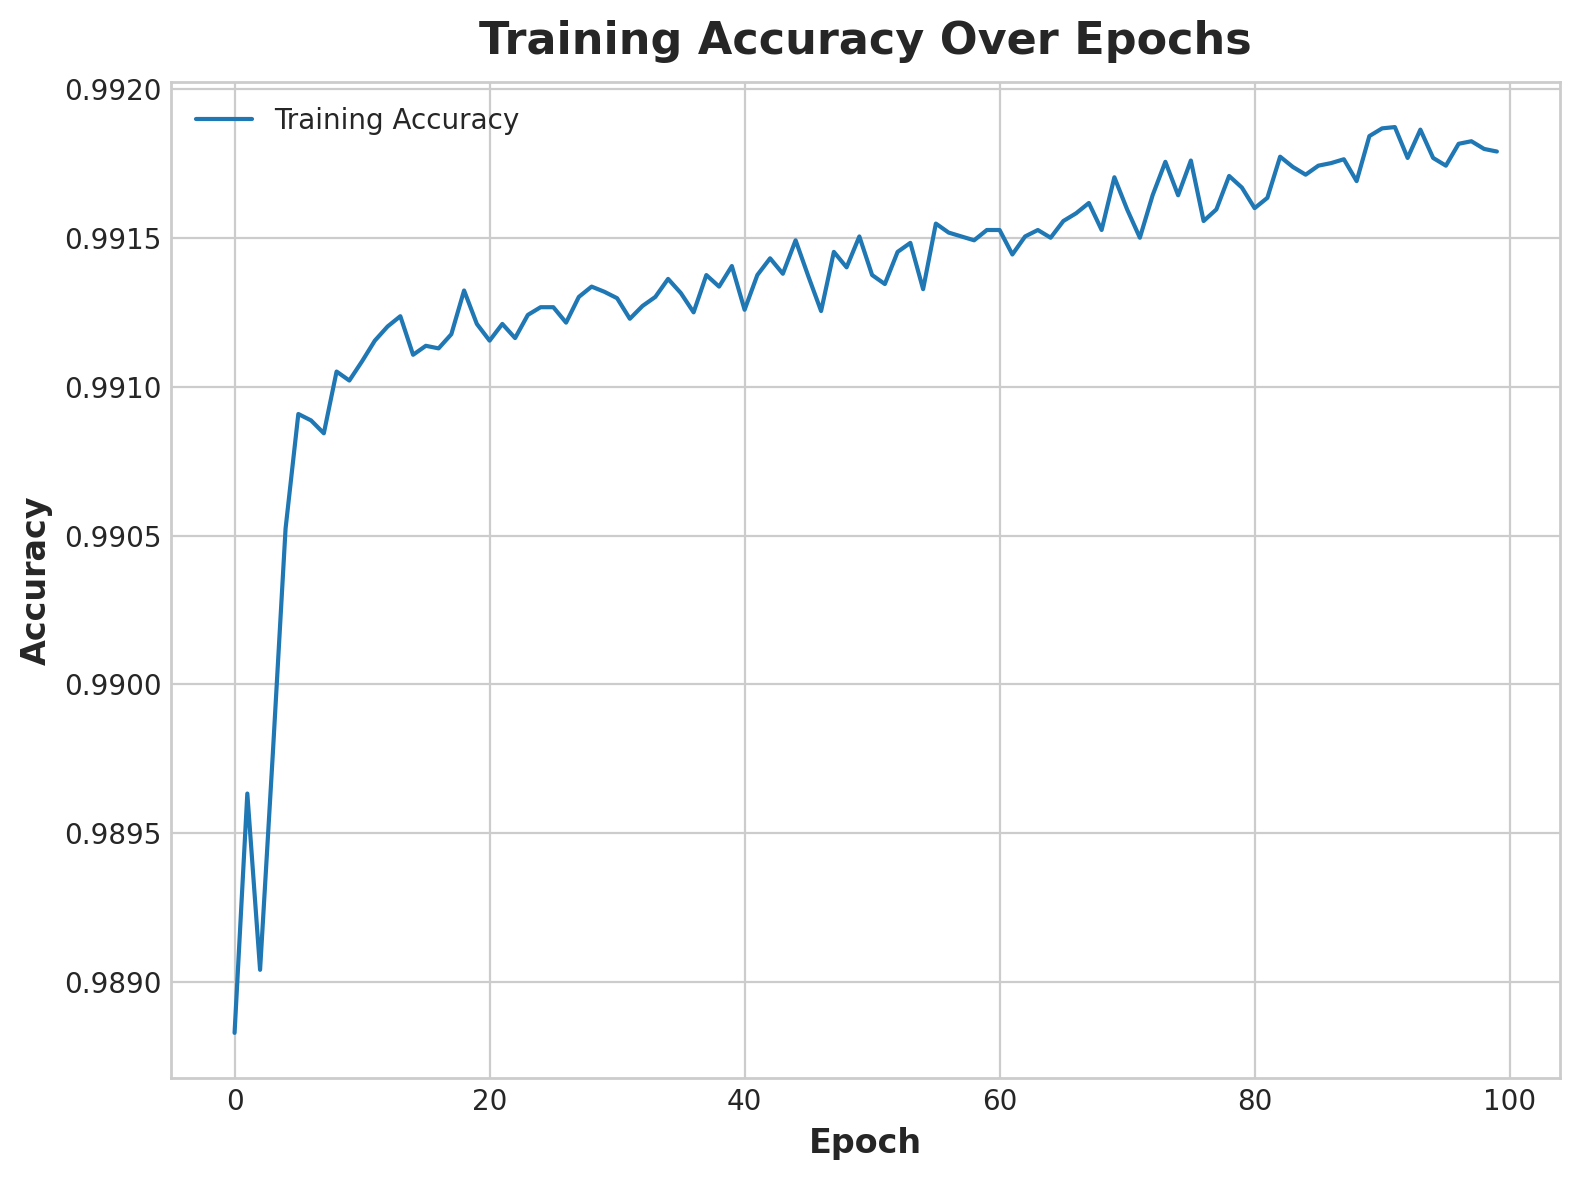

In [28]:
train_acc = history.history['accuracy']
plt.figure(figsize=(8, 6)) 
plt.plot(train_acc, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Over Epochs')
plt.grid(True)
plt.legend()

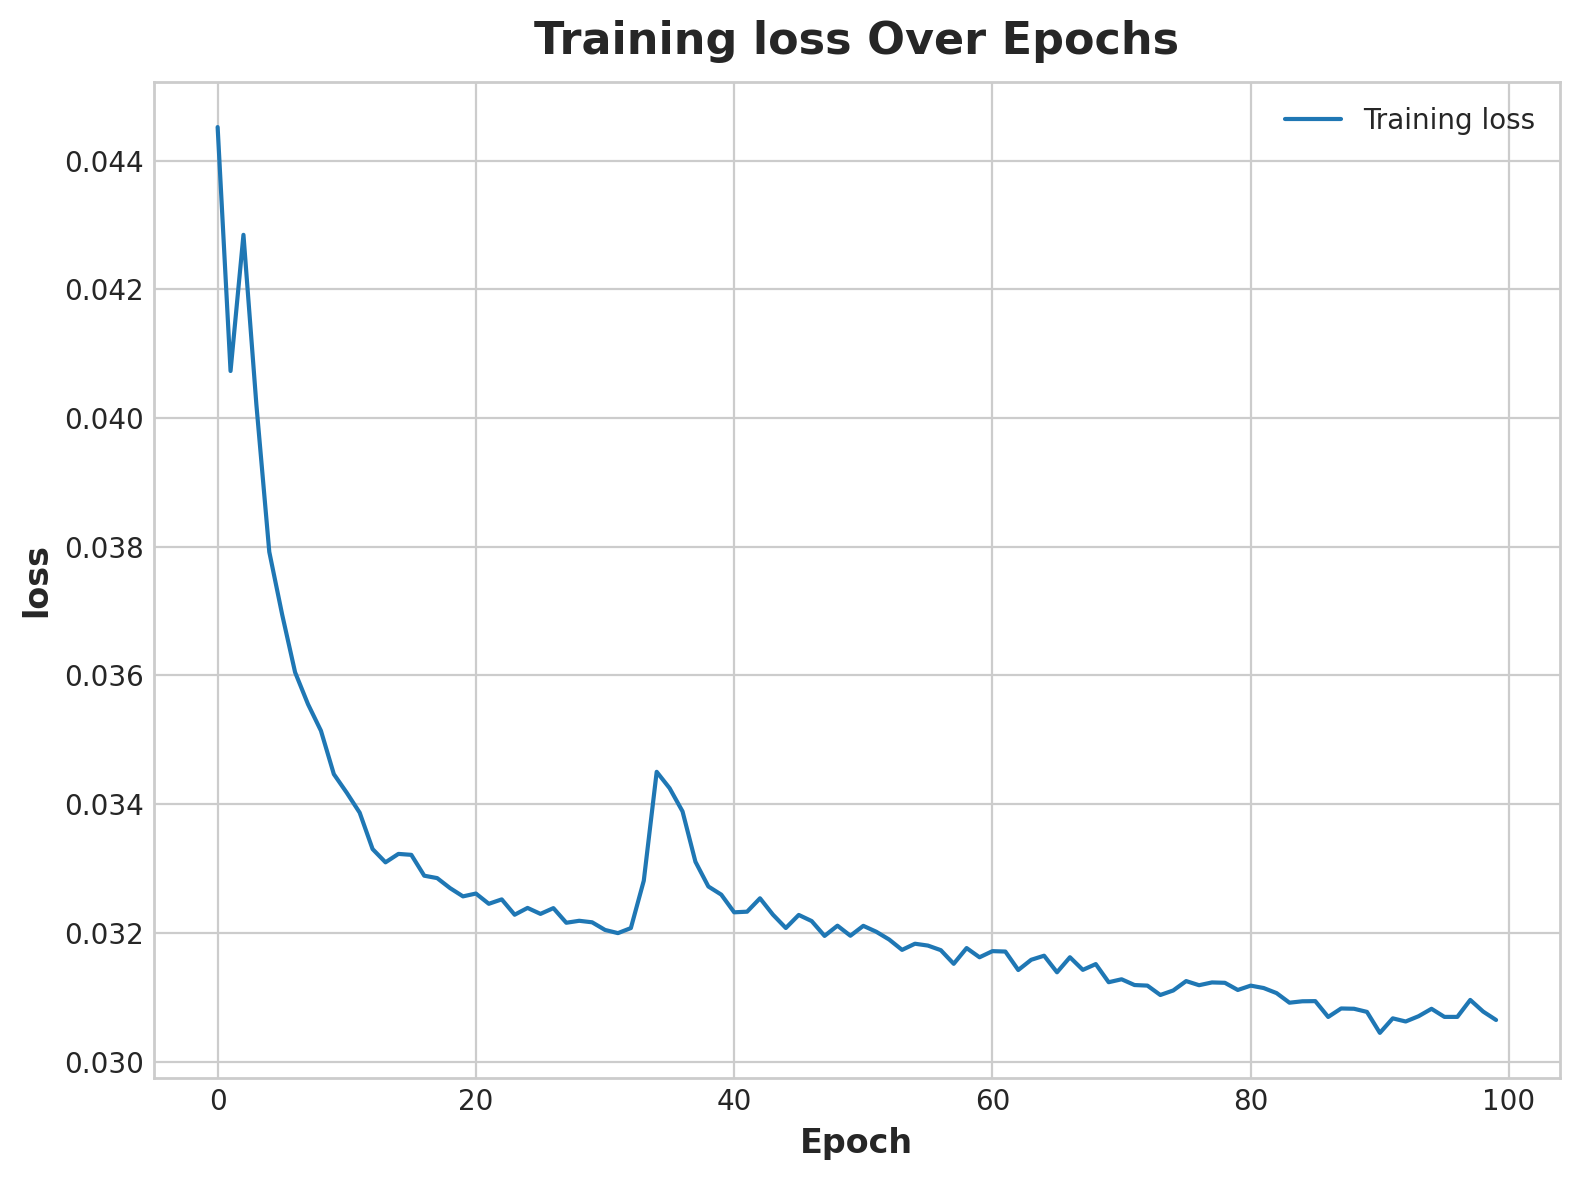

In [29]:
train_loss = history.history['loss']
plt.figure(figsize=(8, 6))
plt.plot(train_loss, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('Training loss Over Epochs')
plt.grid(True)
plt.legend()

In [30]:
train_pred_lstm = model.predict(X_train)
test_pred_lstm = model.predict(X_test)

7232/7232 ━━━━━━━━━━━━━━━━━━━━ 90s 12ms/step
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step


## ***MARKOV CHAIN FOR SHORT TERM PREDICTION***

In [31]:
X_test.shape

(57855, 18)

In [32]:
X_train.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,hour,dayofweek,month,quarter,year,bidaily
datetime,,,,,,,,,,,,,,,,,,
1983-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5,1,1,1983,1
1983-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,5,1,1,1983,2
1983-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5,1,1,1983,1
1983-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,5,1,1,1983,2
1983-01-01 05:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,5,1,1,1983,1


In [33]:
X_train['level'] = y_train
X_train = X_train.loc[:,['level']]
train = X_train.copy()
X_test['level'] = y_test
X_test = X_test.loc[:,['level']]
test = X_test.copy()

In [34]:
X_train.head()

,level
datetime,
1983-01-01 01:00:00,0
1983-01-01 02:00:00,0
1983-01-01 03:00:00,0
1983-01-01 04:00:00,0
1983-01-01 05:00:00,0


In [35]:
states = df['level']
unique_states = np.array([0,1,2])

In [36]:
# Initialize the transition matrix
transition_matrix = pd.DataFrame(0, index=unique_states, columns=unique_states, dtype=float)

# Populate the transition matrix
for (current_state, next_state) in zip(states[:-1], states[1:]):
    transition_matrix.at[current_state,next_state] += 1

In [37]:
# Normalize the transition matrix to get probabilities
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

# Replace NaNs with 0 (in case of rows with no transitions)
transition_matrix = transition_matrix.fillna(0)

print("Transition Matrix:")
print(transition_matrix)

transition_matrix.to_csv('transition_matrix.csv')

Transition Matrix:
          0         1         2
0  0.994399  0.005601  0.000000
1  0.376093  0.571226  0.052681
2  0.001572  0.349057  0.649371


In [38]:
# Initial state (e.g., starting in state 'A')
initial_state = np.array([0, 0, 1])  # State A

# Convert transition matrix to numpy array for matrix multiplication
transition_matrix_np = transition_matrix.values

# Number of steps to predict
num_steps = 5

# Initialize the state distribution with the initial state
state_distribution = initial_state

# Forecast
for _ in range(num_steps):
    state_distribution = np.dot(state_distribution, transition_matrix_np)
    print(f"State distribution after step {_+1}: {state_distribution.argmax()}")


State distribution after step 1: 2
State distribution after step 2: 2
State distribution after step 3: 1
State distribution after step 4: 0
State distribution after step 5: 0


In [39]:
transition_matrix_np = transition_matrix.values
def predict_markov(input_value):
    if input_value == 0:
        input_value = [1,0,0]
    elif input_value == 1:
        input_value = [0,1,0]
    elif input_value == 2:
        input_value = [0,0,1]
        
    initial_state = np.array(input_value)
    state_distribution = initial_state
    return(np.dot(state_distribution, transition_matrix_np))


In [40]:
X_train['markov'] = X_train['level'].shift().fillna(0).apply(predict_markov)
X_train['lstm'] = list(train_pred_lstm)
X_train['ensemble'] = (X_train['markov'] *0.5)+(X_train['lstm']*0.5)
X_train['prediction'] = X_train['ensemble'].apply(lambda x: x.argmax())
X_train['prediction_lstm'] = X_train['lstm'].apply(lambda x: x.argmax())
X_train['prediction_markov'] = X_train['markov'].apply(lambda x: x.argmax())

In [41]:
X_test['markov'] = X_test['level'].shift().fillna(0).apply(predict_markov)
X_test['lstm'] = list(test_pred_lstm)
X_test['ensemble'] = (X_test['markov'] *0.2)+(X_test['lstm']*0.8)
X_test['prediction'] = X_test['ensemble'].apply(lambda x: x.argmax())
X_test['prediction_lstm'] = X_test['lstm'].apply(lambda x: x.argmax())
X_test['prediction_markov'] = X_test['markov'].apply(lambda x: x.argmax())

# **ENSEMBLE OUTPUT**

In [42]:
accuracy = accuracy_score(X_test['level'], X_test['prediction'])

print(f"Ensemble Accuracy: {accuracy * 100:.2f}%")

Ensemble Accuracy: 97.96%


In [43]:
print(classification_report(X_test['level'], X_test['prediction']))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55996
           1       0.69      0.46      0.55      1580
           2       0.74      0.54      0.63       279

    accuracy                           0.98     57855
   macro avg       0.81      0.67      0.72     57855
weighted avg       0.98      0.98      0.98     57855



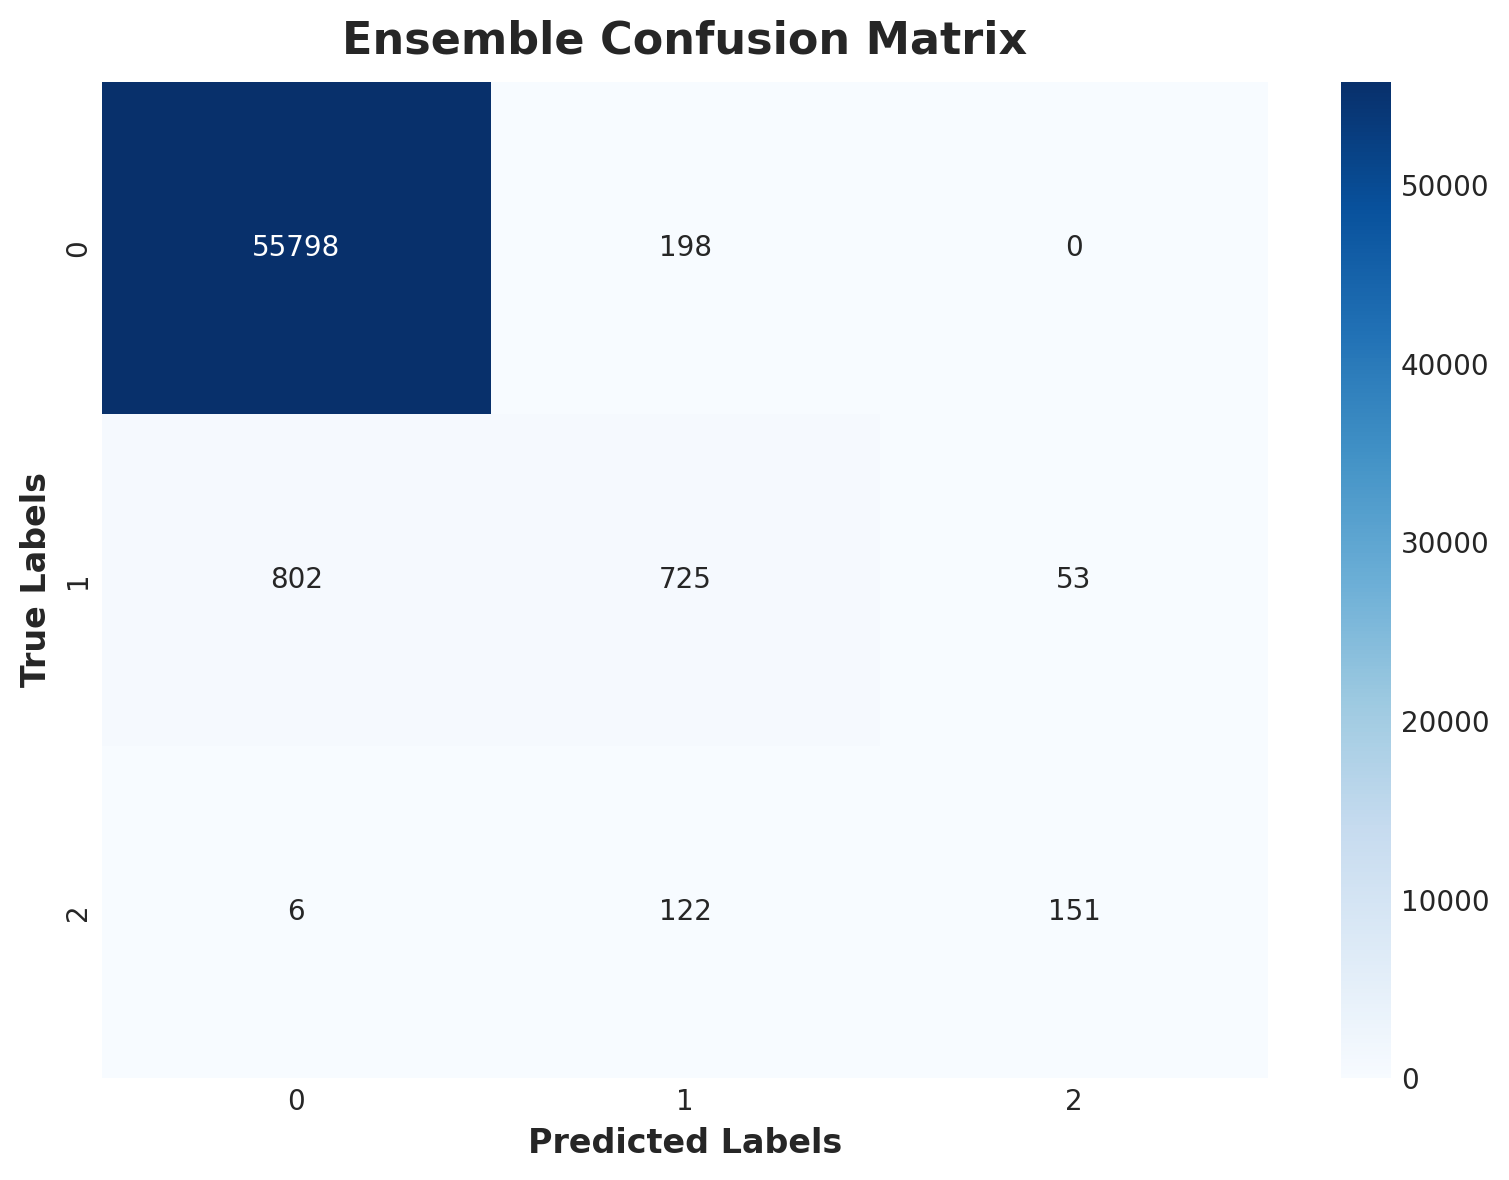

In [44]:
conf_matrix = confusion_matrix(X_test['level'], X_test['prediction'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# **LSTM OUTPUTS**

In [45]:
accuracy = accuracy_score(X_test['level'], X_test['prediction_lstm'])

print(f"LSTM Accuracy: {accuracy * 100:.2f}%")

LSTM Accuracy: 97.92%


In [46]:
print(classification_report(X_test['level'], X_test['prediction_lstm']))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55996
           1       0.69      0.45      0.54      1580
           2       0.73      0.52      0.61       279

    accuracy                           0.98     57855
   macro avg       0.80      0.65      0.71     57855
weighted avg       0.98      0.98      0.98     57855



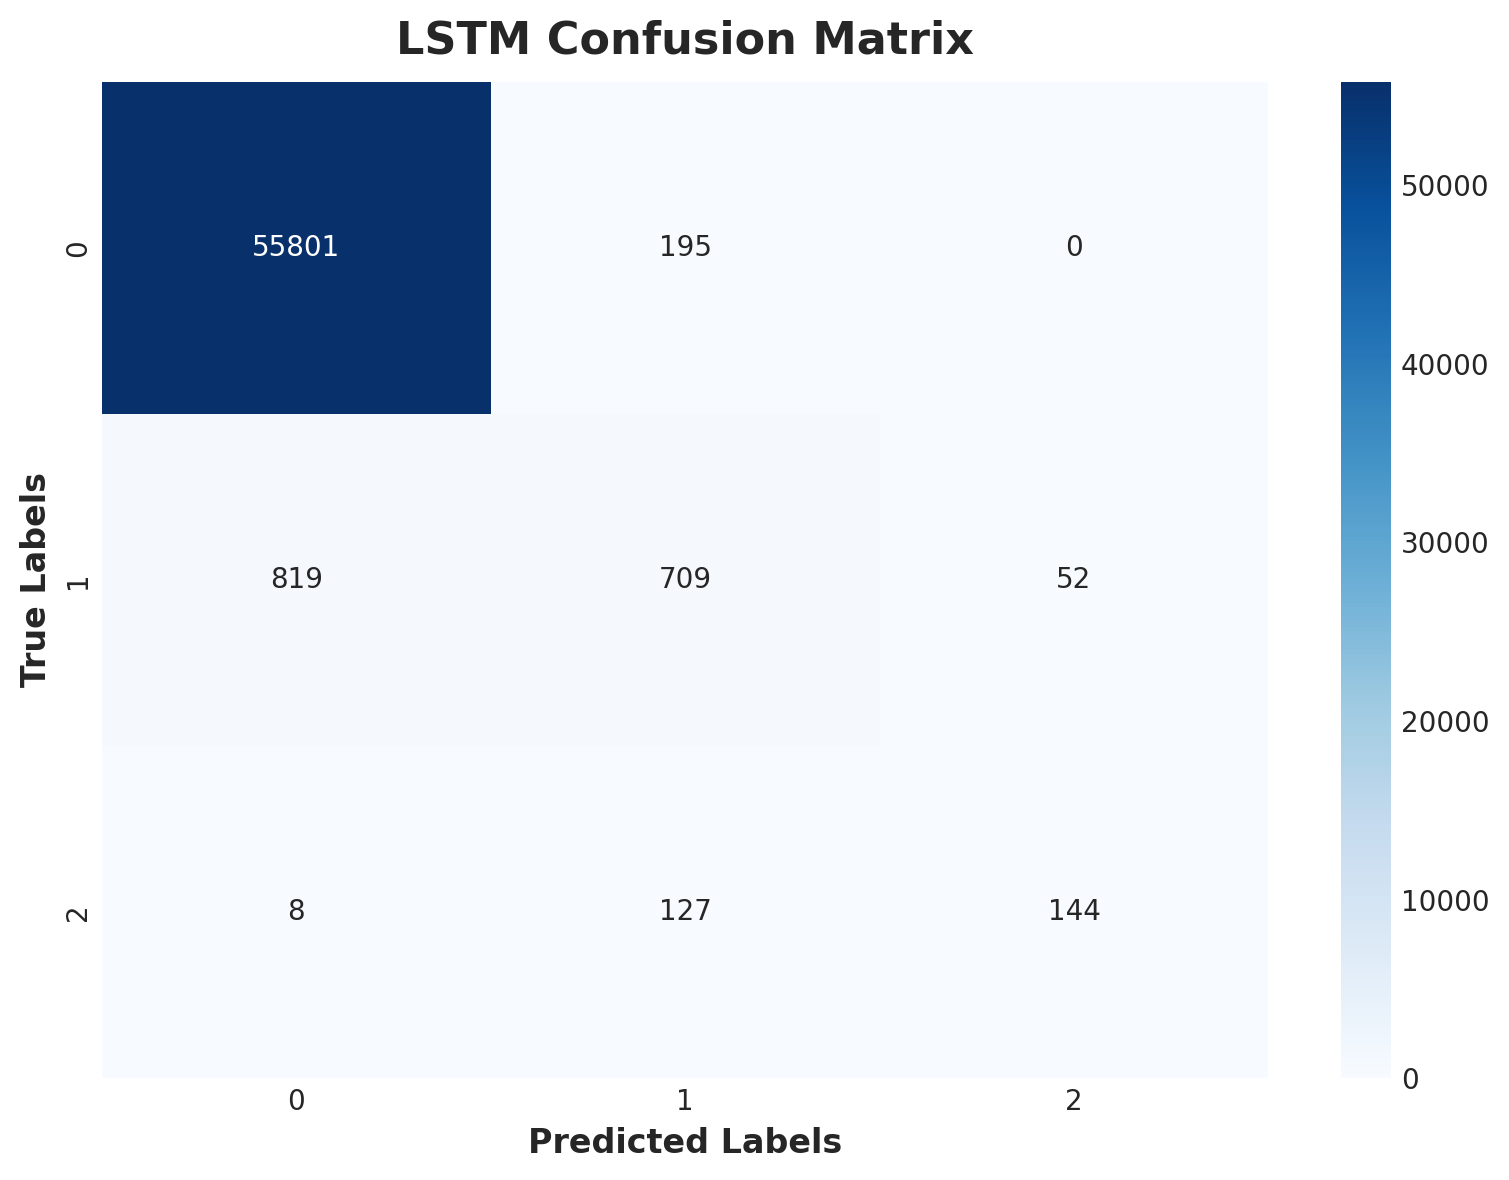

In [47]:
conf_matrix = confusion_matrix(X_test['level'], X_test['prediction_lstm'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


# **MARKOV OUTPUTS**

In [48]:
#accuracy = 
accuracy = accuracy_score(X_test['level'], X_test['prediction_markov'])

print(f"Markov Accuracy: {accuracy * 100:.2f}%")

Markov Accuracy: 97.73%


In [49]:
print(classification_report(X_test['level'], X_test['prediction_markov']))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     55996
           1       0.58      0.58      0.58      1580
           2       0.66      0.66      0.66       279

    accuracy                           0.98     57855
   macro avg       0.75      0.75      0.75     57855
weighted avg       0.98      0.98      0.98     57855



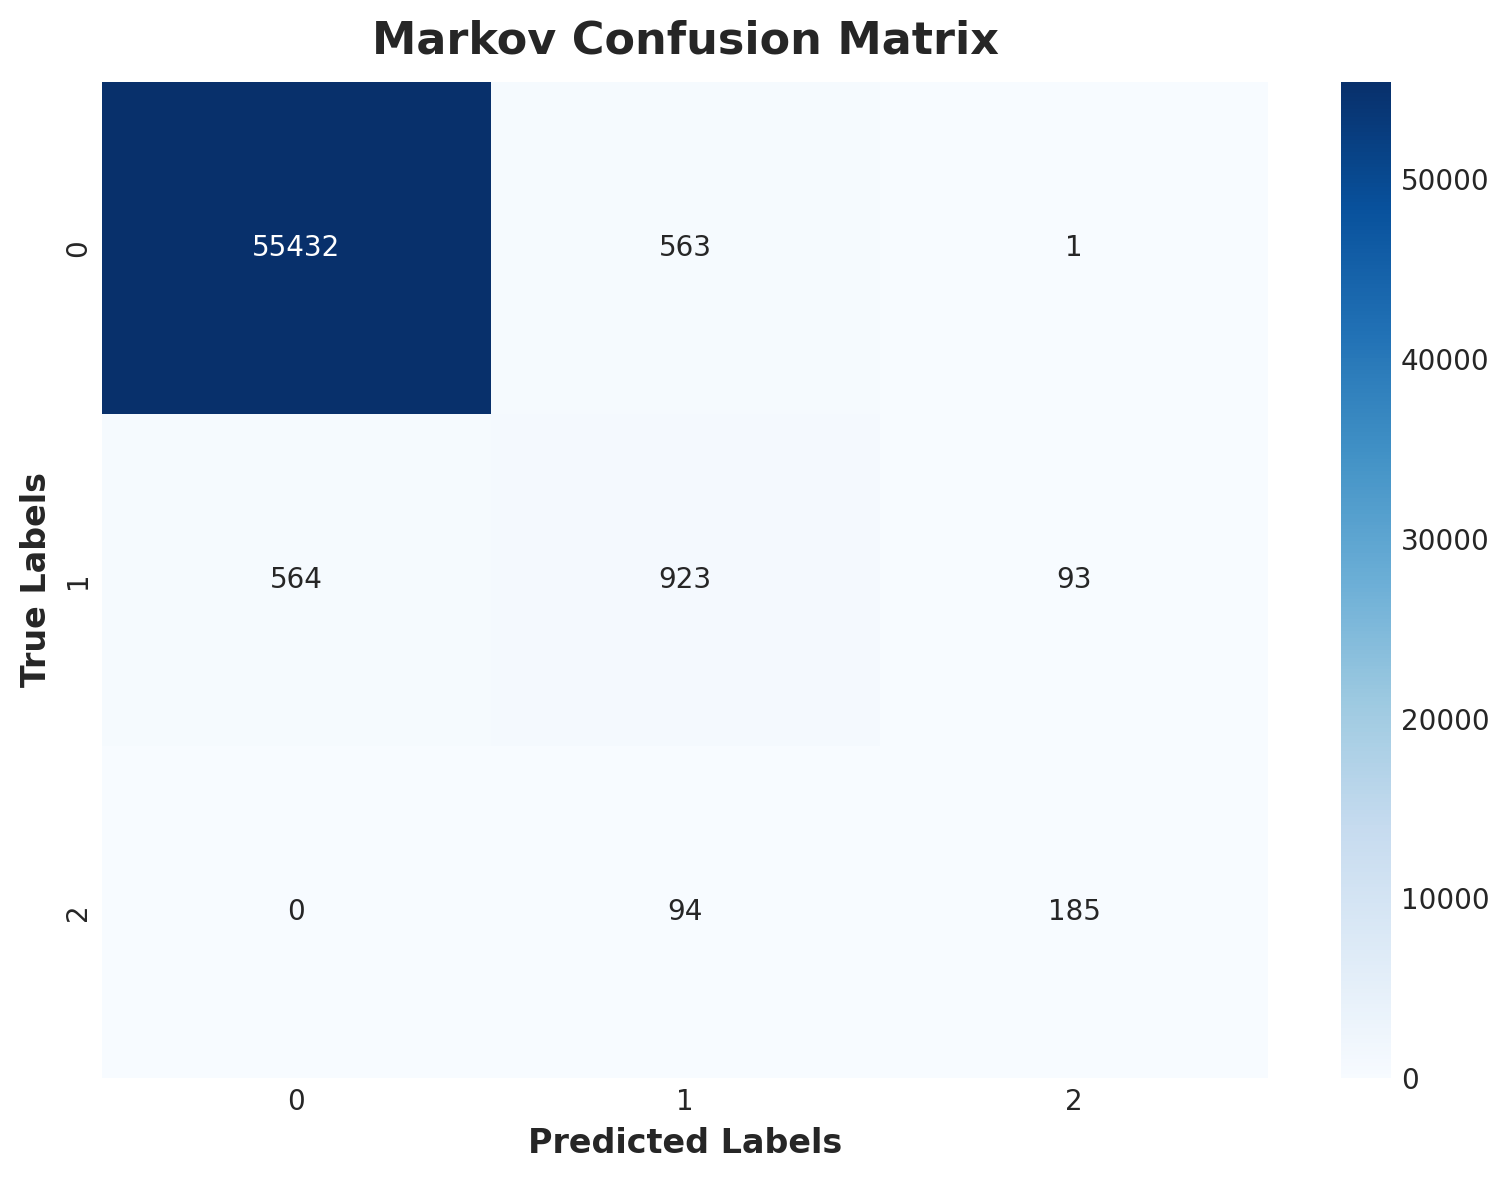

In [50]:
conf_matrix = confusion_matrix(X_test['level'], X_test['prediction_markov'])

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Markov Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [51]:
X_test['prediction_markov'].value_counts()

prediction_markov
0    55996
1     1580
2      279
Name: count, dtype: int64

In [52]:
X_test['prediction_lstm'].value_counts()

prediction_lstm
0    56628
1     1031
2      196
Name: count, dtype: int64

In [53]:
X_test['prediction'].value_counts()

prediction
0    56606
1     1045
2      204
Name: count, dtype: int64

In [54]:
model.save('LSTM.h5')